# ITI5201 Machine Learning Assignment 2

#### Eddy, 33495068 

### Perceptron vs Neural Networks

2.1 Load Task2B train.csv and Task2B test.csv datasets, plot the training and testing data separately in two plots. Mark the data with di↵erent labels in different colors.

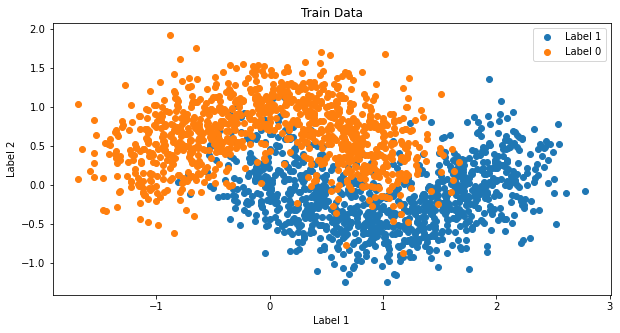

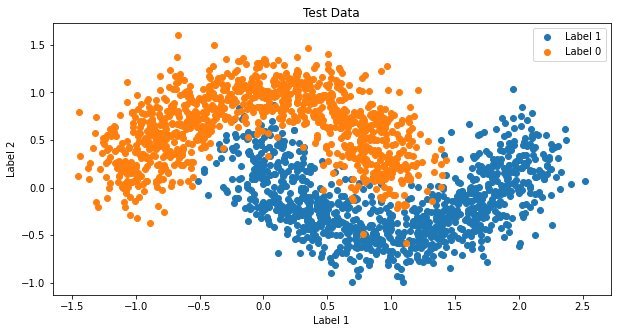

In [1]:
#Import library 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

#Load the Dataset
train_data = pd.read_csv('Task2B_train.csv')
test_data = pd.read_csv('Task2B_test.csv')

# Extracting the features and the labels from the dataset
features_train = train_data.iloc[:, :-1]
labels_train = train_data.iloc[:, -1]
features_test = test_data.iloc[:, :-1]
labels_test = test_data.iloc[:, -1]

# Plot training data
plt.figure(figsize=(10, 5))
for label in labels_train.unique():
    # Filter data by label
    data_to_plot = features_train[labels_train == label]
    plt.scatter(data_to_plot.iloc[:, 0], data_to_plot.iloc[:, 1], label=f'Label {label}')

#Naming the graph
plt.title('Train Data')
plt.xlabel('Label 1')
plt.ylabel('Label 2')
plt.legend()
plt.show()

# Plot testing data
plt.figure(figsize=(10, 5))
for label in labels_test.unique():
    # Filter data by label
    data_to_plot = features_test[labels_test == label]
    plt.scatter(data_to_plot.iloc[:, 0], data_to_plot.iloc[:, 1], label=f'Label {label}')

#Naming the graph
plt.title('Test Data')
plt.xlabel('Label 1')
plt.ylabel('Label 2')
plt.legend()
plt.show()

2.1 Train two Perceptron models on the loaded training data by setting the learning rates $\eta$ to 0.1 and 1.0 respectively. Calculate the test errors of two models and find the best $\eta$ and its corresponding model, then plot the decision boundary and the test data in one plot. Hint: We expect the decision boundary of your perceptron to be a linear function that separates the testing data into two parts. You may also choose to change the labels from [0, 1] to [-1,+1] for your convenience.

In [2]:
#Initialize the perceptron class
class Perceptron:
    #Initialize the parameters
    def __init__(self, eta=0.01, tau_max=10000, epsilon=0.005, random_state=None):
        self.eta = eta   # learning rate
        self.tau_max = tau_max   # max number of iterations
        self.epsilon = epsilon   # tolerable error
        self.random_state = random_state
    #Making the fit function
    def fit(self, x, y):
        #Setting the random state
        RNG = np.random.default_rng(self.random_state)
        n, p = x.shape

        self.w_trace_ = np.empty((self.tau_max, p))     # trace of weights during training
        self.xy_idx_trace_ = np.empty(self.tau_max, int) # trace of considered training point indices
        
        # Initialize the number of iteration and weight
        tau = 0 
        self.w_ = self.w_trace_[0,:] = RNG.normal(size=p) 
        terminate = False
        while not (terminate or (self.predict(x)!=y).mean()<self.epsilon):
            # random order to consider training data
            order = RNG.choice(np.arange(n),size = n ,replace = False)
            #Fitting the weght
            for i in range(n):
                if self.predict(x[order][i]) != y[order][i]:
                    self.w_ = self.w_ + (2*y[order][i]-1)*self.eta * x[order][i]
                
                self.w_trace_[tau+1] = self.w_
                self.xy_idx_trace_[tau] = order[i]
                #Adding to the iteration number
                tau +=1
                #Setting the termination condition
                if tau == self.tau_max-1:
                    terminate = True
                    break
        
        # remove empty rows from traces
        self.w_trace_ = self.w_trace_[:tau] 
        self.xy_idx_trace_ = self.xy_idx_trace_[:tau-1]

        return self

    #Function to predict based on the data
    def predict(self, x):
        return (x.dot(self.w_) >= 0).astype(int)


In [3]:
#Import the library
from sklearn.metrics import zero_one_loss

#Splitting the train and test data
x_train = train_data.iloc[:, :-1].values
y_train = train_data.iloc[:, -1].values
x_test = test_data.iloc[:, :-1].values
y_test = test_data.iloc[:, -1].values

#Running the perceptron algorithm with 0.1 learning rate
perceptron1 = Perceptron(eta=0.1, random_state=13)
perceptron1.fit(x_train, y_train)

#Checking the train and test error
train_error1 = zero_one_loss(perceptron1.predict(x_train), y_train)
test_error1 = zero_one_loss(perceptron1.predict(x_test), y_test)

print('The train error is = ', train_error1, ' while the test error is = ', test_error1)

The train error is =  0.14800000000000002  while the test error is =  0.14200000000000002


In [4]:
#Running the perceptron algorithm with 0.1 learning rate
perceptron2 = Perceptron(eta=1.0, random_state=13)
perceptron2.fit(x_train, y_train)

#Checking the train and test error
train_error2 = zero_one_loss(perceptron2.predict(x_train), y_train)
test_error2 = zero_one_loss(perceptron2.predict(x_test), y_test)

print('The train error is = ', train_error2, ' while the test error is = ', test_error2)

The train error is =  0.14600000000000002  while the test error is =  0.134


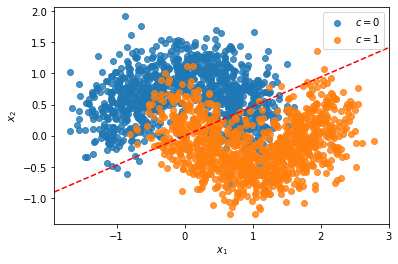

In [5]:
#Initializing the def to plot the data
#Scatter the data
def scatter_data_by_target_value(x, y, ax=None, scatter_params={'alpha': 0.8}):
    ax = plt.gca() if ax is None else ax
    for c in range(2):
        x1_c = x[y==c, 0]
        x2_c = x[y==c, 1]
        ax.scatter(x1_c, x2_c, label=f'$c={c}$', **scatter_params)
    ax.legend()
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
#Making the plot line
def plot_line(slope, intercept, ax=None, shape='--', **kwargs):
    ax = plt.gca() if ax is None else ax
    x_vals = np.array(ax.get_xlim())
    y_vals = intercept + slope * x_vals
    ax.set_ylim(ax.get_ylim())
    ax.set_xlim(ax.get_xlim())
    ax.plot(x_vals, y_vals, shape, **kwargs)
#Making decision bondary
def plot_decision_boundary_from_weights(weights, ax=None):
    slope = -weights[0]/weights[1]
    intercept = 0
    plot_line(slope, intercept, ax, shape='--', color='red')

#Putting the perceptron 1 data to be plotted
scatter_data_by_target_value(x_train, y_train)
plot_decision_boundary_from_weights(perceptron1.w_)
plt.show()

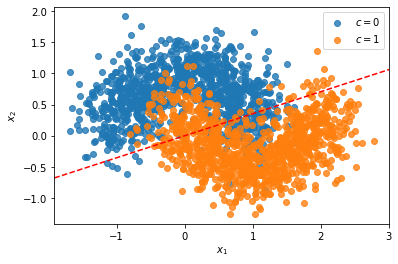

In [6]:
#Putting the perceptron 2 data to be plotted
scatter_data_by_target_value(x_train, y_train)
plot_decision_boundary_from_weights(perceptron2.w_)
plt.show()

2.3 For each combination of K (i.e, number of units in the hidden layer) in 5, 10, 15, ..., 40, (i.e. from 5 to 40 with a step size of 5), and $\eta$ (i.e., learning rate) in 0.01, 0.001 run the 3-layer Neural Network and record testing error for each of them. Plot the effect of dfferent K values on the accuracy of the testing data. Based on this plot, find the best combination of K and $\eta$ and obtain your best model, then plot the decision boundary and the test data in one plot.

Activation Function


In [7]:
# auxiliary functions 
## the activation function, tanh
def h(z):
    return (np.tanh(z))

## the derivative of the tanh functiion
def h_d(z):
    return (1 - np.tanh(z)**2)

## Accuracy
def accuracy(pred, label):
    return (pred == label).mean()

In [8]:
#Feedforward function
def feedforward(Xi, Ti, W1, b1, W2, b2):
    ### Input Layer 
    a1 = Xi                           
    y = Ti                          
    ### Hidden layer
    z2 = a1 @ W1 + b1                            
    a2 = h(z2)                                  
    ### Output layer
    z3 = a2 @ W2 + b2                         
    a3 = h(z3)
    ### Return the result                            
    return(a1, a2, a3, y, z2, z3)

In [9]:
#Backpropagation function
def backpropagation(Ti, W2, z2, z3, a3):
    ### Output layer
    d3 = -(Ti-a3) * h_d(z3)                          
    ### Hidden layer
    d2 =  (d3 @ W2.T) * h_d(z2)
    ### Return the result                            
    return(d2,d3)


In [10]:
# Prediction function
def prediction(X, W1, W2, b1, b2, threshold=0):
    # we use the feedforward network we defined to obtain output activation (a3), we don't care about the
    # rest so we use _ to store them. We also don't need to send T so we just send 1 instead
    _,_, a3,_,_,_ = feedforward(X, 1,W1,b1, W2, b2)
    return np.array([1 if above_thresh else -1 for above_thresh in (a3 >= threshold)]).reshape(-1,1)
    

In [11]:
#Neural Network function
def NN(K, eta, X1, T1, X2, T2, epoch_max=500, seed=None):
    if seed is not None: np.random.seed(seed)
    # Setting parameters
    eta = eta #Setting the learning rate, must be inputted by the user
    alpha = 0.0001 #Setting the regularization term
    N,D = X1.shape

    # initialization
    epoch = 1 # epoch (iteration) counter
    terminate = False   # termination criteria

    ## weight vectors/matrices initialization
    ### w stands for weight and b for bias
    ### the numbers after the letters indicates the layer number
    W1 = np.random.randn(D, K) * 1.5
    b1 = np.zeros((1,K))
    W2 = np.random.randn(K,1) * 1.5
    b2 = np.zeros((1,1))
    ## tracing accuracy of the model 
    train_accuracy = []
    test_accuracy = []
    
    # main loop
    while (not terminate):

        
        ## Feedforward:
        a1, a2, a3, y, z2, z3 = feedforward(X1, T1, W1, b1, W2, b2)

        ## Backpropagation:
        d2, d3 = backpropagation(T1, W2, z2, z3, a3)

        ## calculate the delta values
        ### 1st layer
        W1_d = a1.T @ d2
        b1_d = d2
        ### 2nd layer
        W2_d = a2.T @ d3
        b2_d = d3

        ## Updating weight vectors and matrices
        ### Input layer
        W1 = W1 - eta * (W1_d/N + alpha*W1)
        b1 = b1 - eta * (b1_d.mean(axis=0, keepdims=True))
        ### Hidden layer
        W2 = W2 - eta * (W2_d/N + alpha*W2)
        b2 = b2 - eta * (b2_d.mean(axis=0, keepdims=True))

        ## Trace the train  and test accuracy
        train_accuracy.append(accuracy(prediction(X1, W1, W2, b1, b2), T1))
        test_accuracy.append(accuracy(prediction(X2, W1, W2, b1, b2), T2))
        ## increase the iteration counter
        epoch = epoch + 1

        ## check the termination criteria
        if (epoch >= epoch_max): terminate = True

    return (prediction(X1, W1, W2, b1, b2), prediction(X2, W1, W2, b1, b2))


In [12]:
#Setting the y_train and y_test data to be -1, 1
y_train = np.where(y_train == 0, -1, 1)
y_test = np.where(y_test == 0, -1, 1)

#Renaming the dataset
X1, X2, T1, T2 = x_train, x_test, y_train, y_test

#Reshaping the target
T1 = T1.reshape(-1, 1)
T2 = T2.reshape(-1, 1)

#Setting the K and learning rate list
k_value = list(range(5, 41, 5))
learning_rates = [0.01, 0.001]

#Initializing the empty list to store the all the test error and the result
test_nn_error1 = []
test_nn_error2 = []
test1 = []
test2 = []

#Running the Neural Network for all k value and learning rates
for k in k_value:
    for l in learning_rates:
        #Running the neural network with 2000 repetition
        train, test = NN(k, l, X1, T1, X2, T2, epoch_max = 2000, seed= 13)
        #Storing the result for 0.01 learning rate
        if l == 0.01:
            test_nn_error1.append(zero_one_loss(test, T2))
            test1.append(test)
        #Storing the result for 0.1 learning rate
        else:
            test_nn_error2.append(zero_one_loss(test, T2))
            test2.append(test)

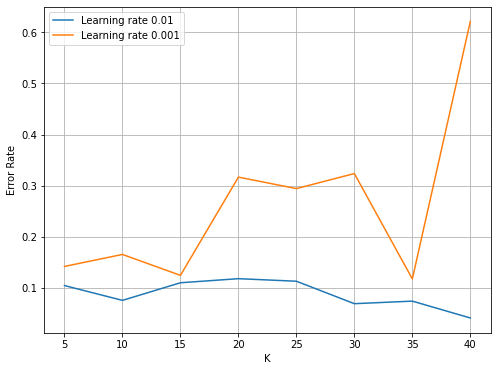

In [13]:
#Initializing the plot
fig, axs = plt.subplots(1, 1)
#Setting the width and height of the plot
fig.set_figwidth(8)
fig.set_figheight(6)

#Plotting the error rates for both learning rate
axs.plot(k_value, test_nn_error1, label='Learning rate 0.01')
axs.plot(k_value, test_nn_error2, label='Learning rate 0.001')

#Naming the x and y label
axs.set_xlabel('K')
axs.set_ylabel('Error Rate')

#Adding a grid to the plot
axs.grid()

#Adding the legend to the plot
axs.legend()

# Display the plot
plt.show()


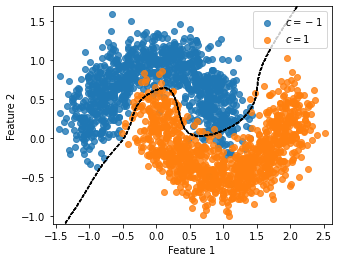

In [14]:
#Definte the range by extending the min and max values of the test set
x1_min, x1_max = x_test[:, 0].min() - 0.1, x_test[:, 0].max() + 0.1
x2_min, x2_max = x_test[:, 1].min() - 0.1, x_test[:, 1].max() + 0.1

#Creating a meshgrid
xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, 0.01),
                       np.arange(x2_min, x2_max, 0.01))

#Using the NN function to predict the outcomes over the entire grid to give pattern for the decision boundary
_, Z = NN(40, 0.01, X1, T1, np.c_[xx1.ravel(), xx2.ravel()], 1 , epoch_max=2000, seed=13)
#Reshape the output to match the grid shape
Z = Z.reshape(xx1.shape)

#Initialize the figure
plt.figure(figsize=(5,4))
#Plot the decision boundary by drawing contours based on the Z we predicted before
plt.contour(xx1, xx2, Z, colors='black', linewidths=1, linestyles='dashed')
#Scatter plot of the test samples, colored by their label
for c in [-1, 1]:
    plt.scatter(x_test[(y_test.squeeze()==c,0)], x_test[(y_test.squeeze()==c,1)], label=f'$c={c}$', alpha=0.8)

#Set the labels for the x and y axes
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
#Add a legend to the plot to identify different classes
plt.legend()
#Showing the plot
plt.show()

2.4 Explain the reason(s) responsible for such difference between Perceptron and a 3-layer Neural Network by comparing the plots you generated in Steps II and III. Hint: Look at the plots and think about the model assumptions.

The fundamental difference between a perceptron and a 3-layer Neural Network is that the perceptron is essentialy a linear classifier while neural network introduces non linearity.

Perceptron as mentioned before is a essentialy a linear classifier which means the decision boundary for this algorithm is linear. A perceptron makes prediction based on linear combination of the input features. This means that perceptron separates the output to either 0 or one which explains why the decision boundary is linear. Due to this feature, perceptron perform well with linearly separable data but will be unable to separate the data if the data is not linearly separable. Looking at the data spread, we can see a yin yang shape from the data. This means that the data is not linearly separable since there is no line that can clearly separate the data in two. That's why the decision boundary from perceptron was unable to separate the data since it's just made from a single line.

Neural network meanwhile introduces non-linearity through its use of activation functions in the neuron which is located in the hidden layer. With the activation function, neural network allows the model to learn non-linear decision boundaries, enabling it to model the relationship between the data effectively. We can see from the plotted graph that the decision boundary from the neural network was able to cleanly separate the blue and orange data in two, which shows that the neural network was able to model non-linearity through it usage of activation function. This is also reflected from the lower error rate the neural network has over the perceptron due to it being able to model the decision boundary better.
